In [ ]:
import anndata


In [ ]:
import scanpy


In [ ]:
# /scratch/c9881013/felix_granada/granada/redeconv/redeconv_atlas/Results_4_normalization/scRNA_seq_new_noShift.tsv
# /scratch/c9881013/felix_granada/granada/redeconv/redeconv_atlas/Results_4_normalization/Meta_data_new.tsv


expr cells: 3769, meta cells: 3769, overlap: 3769


/gpfs/gpfs1/scratch/c9881013/.conda_envs/redeconv-env/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/gpfs/gpfs1/scratch/c9881013/.conda_envs/redeconv-env/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


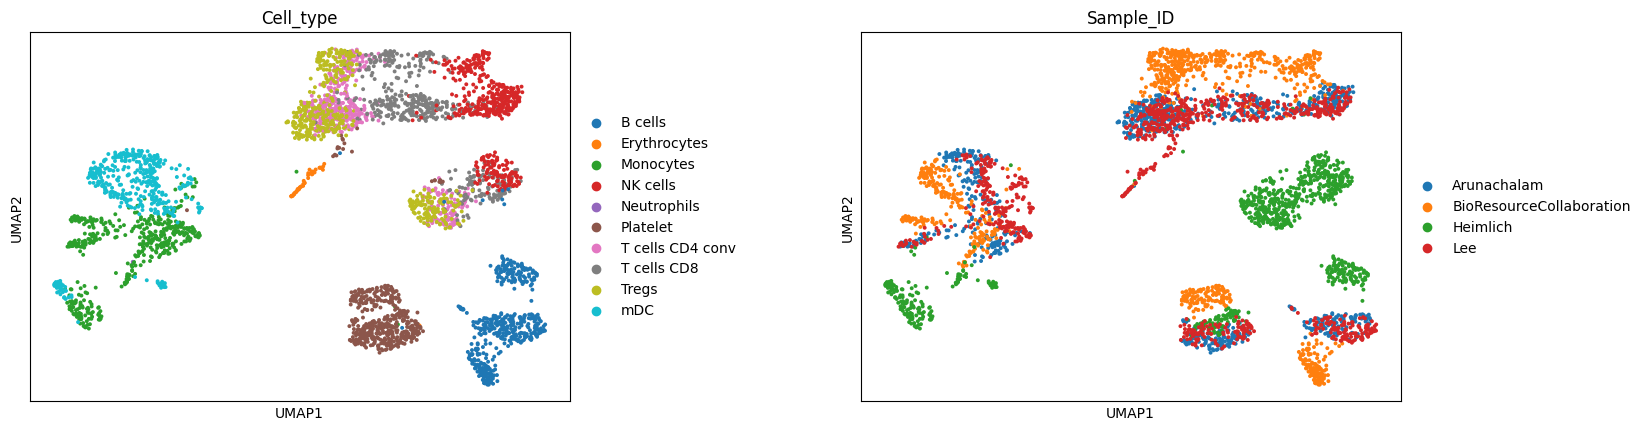

In [10]:
import pandas as pd
import scanpy as sc
import anndata as ad

# Input files (from ReDeconv normalization output)
expr_path = "/scratch/c9881013/felix_granada/granada/redeconv/redeconv_atlas/Results_4_normalization/scRNA_seq_new_noShift.tsv"
meta_path = "/scratch/c9881013/felix_granada/granada/redeconv/redeconv_atlas/Results_4_normalization/Meta_data_new.tsv"

# Load expression: rows=genes, columns=cells, first column is gene id/name
expr = pd.read_csv(expr_path, sep='\t')
expr = expr.set_index(expr.columns[0])
expr.columns = expr.columns.astype(str).str.strip()

# Load metadata and align to expression cell columns
meta = pd.read_csv(meta_path, sep='\t')
meta['Cell_ID'] = meta['Cell_ID'].astype(str).str.strip()
meta = meta.set_index('Cell_ID')

common_cells = [c for c in expr.columns if c in meta.index]
print(f"expr cells: {len(expr.columns)}, meta cells: {len(meta.index)}, overlap: {len(common_cells)}")
if len(common_cells) == 0:
    raise ValueError('No overlapping cell IDs between expression columns and meta Cell_ID. Check paths/IDs.')

# Build AnnData: rows=cells, cols=genes
adata = ad.AnnData(X=expr[common_cells].T)
adata.obs = meta.loc[common_cells].copy()
adata.obs.index = adata.obs.index.astype(str)
adata.var_names = expr.index.astype(str)

# Standard UMAP pipeline
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=min(2000, adata.n_vars - 1), subset=True)
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=min(30, adata.n_vars - 1))
sc.tl.umap(adata)

# Plot by cell type and sample
sc.pl.umap(adata, color=['Cell_type', 'Sample_ID'], wspace=0.4)
